# MNIST Autoencoder

Same PyTorch Autoencoder implementation as the weather notebook, applied to MNIST digit images to reduce dimensionality and visualize whether the extracted features separate digit classes.

In [30]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from torchvision import datasets
import os
from scipy import stats

## Data Preparation

In [31]:
mnist_train = datasets.MNIST(root='./data', train=True, download=True)

# Flattening 28x28 images to 784-dim vectors, scaling pixel values to [0, 1]
X_scaled = (mnist_train.data.float() / 255.0).view(-1, 28 * 28).numpy()
X_tensor = torch.FloatTensor(X_scaled)
Y_numerical = mnist_train.targets.numpy()

X_tensor.shape

torch.Size([60000, 784])

## Modelling

In [32]:

# Defining Autoencoder model
class Autoencoder(nn.Module):
    def __init__(self, input_size, encoding_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, encoding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, input_size)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Setting random seed for reproducibility
torch.manual_seed(42)

input_size = X_tensor.shape[1]  # Number of input features
encoding_dim = 3  # Desired number of output dimensions
model = Autoencoder(input_size, encoding_dim)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

# Training the autoencoder
num_epochs = 200
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_tensor)
    loss = criterion(outputs, X_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Loss for each epoch
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Encoding the data using the trained autoencoder
encoded_data = model.encoder(X_tensor).detach().numpy()

Epoch [20/200], Loss: 0.0643
Epoch [40/200], Loss: 0.0579
Epoch [60/200], Loss: 0.0522
Epoch [80/200], Loss: 0.0495
Epoch [100/200], Loss: 0.0472
Epoch [120/200], Loss: 0.0447
Epoch [140/200], Loss: 0.0424
Epoch [160/200], Loss: 0.0407
Epoch [180/200], Loss: 0.0396
Epoch [200/200], Loss: 0.0388


## Visualization

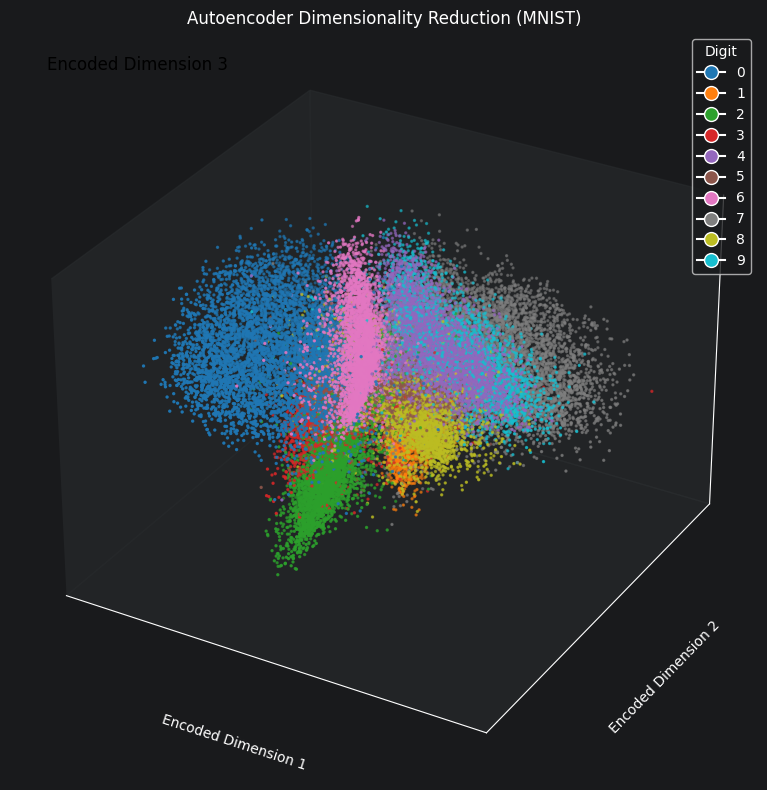

In [33]:
# Plotting the encoded data in 3D space
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(encoded_data[:, 0], encoded_data[:, 1], encoded_data[:, 2], c=Y_numerical, cmap='tab10', s=2)

# Creating a custom legend with the digit classes
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(digit)),
                     markersize=10, label=str(digit)) for digit in np.unique(Y_numerical)]
ax.legend(handles=handles, title="Digit")

# Adjusting the layout to provide more space for labels
ax.xaxis.labelpad = 20
ax.yaxis.labelpad = 20

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Manually adding z-axis label for better visibility
ax.text2D(0.05, 0.95, 'Encoded Dimension 3', transform=ax.transAxes, fontsize=12, color='black')

ax.set_xlabel('Encoded Dimension 1')
ax.set_ylabel('Encoded Dimension 2')
ax.set_title('Autoencoder Dimensionality Reduction (MNIST)')

plt.tight_layout()

plt.savefig('results/MNIST_Autoencoder.png')

plt.show()

## Reconstruction Quality

In [34]:
def compute_mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2)

reconstructed_data = model(X_tensor).detach().numpy()
autoencoder_mse = compute_mse(X_scaled, reconstructed_data)
print(f'Autoencoder Reconstruction MSE: {autoencoder_mse:.4f}')

Autoencoder Reconstruction MSE: 0.0387


In [35]:
pca = PCA(n_components=encoding_dim)
pca_encoded = pca.fit_transform(X_scaled)
pca_reconstructed = pca.inverse_transform(pca_encoded)

pca_mse = compute_mse(X_scaled, pca_reconstructed)
print(f'PCA Reconstruction MSE: {pca_mse:.4f}')

PCA Reconstruction MSE: 0.0518


## Variational Autoencoder

Sampling new digits requires a latent space with a known, continuous distribution to draw from. The plain autoencoder above has no such structure (its latent codes just land wherever reconstruction loss pushes them), which is why generating from it needs a hack like fitting a KDE to `encoded_data`. A VAE fixes this by training the encoder to output a distribution (`mu`, `logvar`) regularized towards `N(0, I)` via a KL-divergence term, so we can generate new digits by sampling `z ~ N(0, I)` directly and decoding it.

In [41]:
class VAE(nn.Module):
    def __init__(self, input_size, latent_dim):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, input_size),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(reconstructed, original, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(reconstructed, original, reduction='sum')
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_divergence

# Using the M1's MPS backend to speed up VAE training, falling back to CPU elsewhere
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Training VAE on: {device}')

# Setting random seed for reproducibility
torch.manual_seed(42)

latent_dim = 6
vae = VAE(input_size, latent_dim).to(device)
X_tensor_device = X_tensor.to(device)

optimizer = optim.Adam(vae.parameters(), lr=0.003)

# Training the VAE
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    reconstructed, mu, logvar = vae(X_tensor_device)
    loss = vae_loss(reconstructed, X_tensor_device, mu, logvar) / X_tensor_device.size(0)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Loss for each epoch
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Training VAE on: mps
Epoch [20/1000], Loss: 222.9361
Epoch [40/1000], Loss: 205.8779
Epoch [60/1000], Loss: 198.2036
Epoch [80/1000], Loss: 194.0131
Epoch [100/1000], Loss: 189.4830
Epoch [120/1000], Loss: 183.6647
Epoch [140/1000], Loss: 178.2890
Epoch [160/1000], Loss: 170.1630
Epoch [180/1000], Loss: 165.7774
Epoch [200/1000], Loss: 161.4232
Epoch [220/1000], Loss: 157.0234
Epoch [240/1000], Loss: 154.1263
Epoch [260/1000], Loss: 149.7142
Epoch [280/1000], Loss: 147.4628
Epoch [300/1000], Loss: 145.3977
Epoch [320/1000], Loss: 144.1583
Epoch [340/1000], Loss: 142.5536
Epoch [360/1000], Loss: 143.5121
Epoch [380/1000], Loss: 140.6138
Epoch [400/1000], Loss: 139.6053
Epoch [420/1000], Loss: 138.7762
Epoch [440/1000], Loss: 138.0941
Epoch [460/1000], Loss: 138.7192
Epoch [480/1000], Loss: 136.9420
Epoch [500/1000], Loss: 136.3048
Epoch [520/1000], Loss: 135.8824
Epoch [540/1000], Loss: 136.0706
Epoch [560/1000], Loss: 134.9510
Epoch [580/1000], Loss: 134.5970
Epoch [600/1000], Loss: 13

## Generation

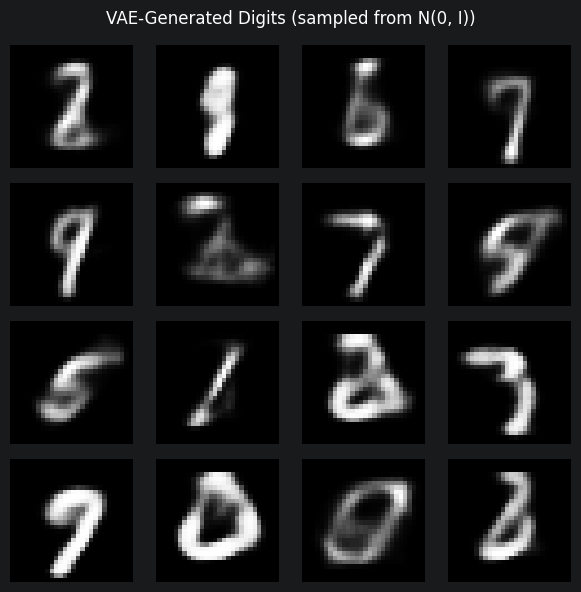

In [42]:

# Sampling new digits by drawing z directly from the VAE's N(0, I) prior
num_samples = 16
with torch.no_grad():
    z_samples = torch.randn(num_samples, latent_dim, device=device)
    generated = vae.decode(z_samples).view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, img in zip(axes.flatten(), generated):
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle('VAE-Generated Digits (sampled from N(0, I))')
plt.tight_layout()
plt.savefig('results/VAE_Generated_Digits.png')
plt.show()